# 04 Clustering

El modelo global de LightGBM funcionó muy bien dentro en el entrenamiento (R² ≈ 0.94 en validación cruzada espacial), pero al evaluarlo en el conjunto de test reveló una caída de 0.23 puntos en el R² (R² ≈ 0.71). El desglose por condado mostró que esa caída no era uniforme: el modelo predecía con excelencia en zonas parecidas al Valle Central (Riverside 0.95, Solano 0.93) pero fallaba en zonas con caracteristicas extremas como el desierto (Inyo -2.53), la alta montaña (Mono 0.007) y la costa (Santa Barbara 0.46). La conclusión fue que un único modelo no puede aprender simultáneamente la lógica agrícola de regímenes climáticos tan distintos, porque promedia relaciones biofísicas que son fundamentalmente diferentes entre regiones. De ahí la decisión de regionalizar: agrupar las parcelas por características edafoclimáticas y entrenar un modelo especializado por cada régimen.

# Importar librerias

In [1]:
import polars as pl
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
import os
import joblib
import geopandas as gpd
import requests
import zipfile
import io
import random
import json
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Configuración

In [2]:
# Cargar shapefile Census TIGER
url_tiger = (
    "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/"
    "tl_2022_us_county.zip"
)

print("Descargando shapefile Census TIGER...")
response = requests.get(url_tiger, timeout=60)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall("/tmp/tiger_counties")

gdf_us_counties = gpd.read_file("/tmp/tiger_counties/tl_2022_us_county.shp")

gdf_counties = (
    gdf_us_counties[gdf_us_counties['STATEFP'] == '06']
    .rename(columns={'NAME': 'name'})
    .to_crs('EPSG:4326')
    .reset_index(drop=True)
)

print(f"Condados de California: {len(gdf_counties)}")

Descargando shapefile Census TIGER...
Condados de California: 58


In [3]:
#Función de norte en los mapas

def agregar_norte(ax, x=0.95, y=0.97, size=0.045):
    """
    Añade una flecha de norte estilo cartográfico (mitad negra, mitad blanca)
    en coordenadas relativas al eje (0-1).

    Parámetros
    ----------
    ax   : eje de matplotlib
    x, y : posición del centro de la flecha (relativa al eje, 0-1)
    size : tamaño relativo de la flecha
    """
    fig = ax.get_figure()
    ax_bbox = ax.get_position()

    # Convertir coordenadas relativas al eje en coordenadas de figura
    cx = ax_bbox.x0 + x * ax_bbox.width
    cy = ax_bbox.y0 + y * ax_bbox.height

    h = size * 1.8   # altura de la flecha
    w = size * 0.55  # semi-ancho de la base

    # Mitad izquierda (negra)
    tri_izq = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx,     cy - h * 0.55]],
        transform=fig.transFigure,
        color='black', zorder=10, clip_on=False
    )

    # Mitad derecha (blanca con borde negro)
    tri_der = plt.Polygon(
        [[cx,     cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        color='white', zorder=10, clip_on=False,
        ec='black', linewidth=0.8
    )

    # Contorno exterior
    contorno = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        fill=False, ec='black', linewidth=1.0,
        zorder=11, clip_on=False
    )

    fig.add_artist(tri_izq)
    fig.add_artist(tri_der)
    fig.add_artist(contorno)

    # Letra N
    fig.text(
        cx, cy + h * 0.52,
        'N',
        transform=fig.transFigure,
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='black', zorder=12,
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )


In [4]:
#Ubicación de resultados 

OUTPUT_DIR = "C:/Users/lesli/Documents/TFM/notebooks/cluster_outputs"
# Creamos la carpeta automáticamente si no existe (exist_ok=True evita que lance error si ya existe)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Carpeta de almacenamiento lista en: '{OUTPUT_DIR}'")

Carpeta de almacenamiento lista en: 'C:/Users/lesli/Documents/TFM/notebooks/cluster_outputs'


# Importar base de Datos

In [5]:
df = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")
df.head(5)

year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585,lon,lat,county,I_GDD,I_temp,I_precip,I_suelo,IAI
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,-120.703207,37.125374,"""Merced""",0.06268,1.0,0.0,0.55,0.378804
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,-119.113253,35.622238,"""Kern""",0.386,1.0,0.0,0.391304,0.444061
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null,-121.880199,39.018031,"""Colusa""",0.50864,1.0,0.0,0.666667,0.535925
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null,-119.128831,35.717057,"""Kern""",0.84484,1.0,0.0,0.366667,0.576785
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null,-120.119889,37.04136,"""Madera""",0.51692,1.0,0.0,0.591026,0.523281


# Configuración cluster

In [6]:
# Variables biofísicas para el clustering
# Clima + suelo (las mismas features del modelo, agregadas por parcela)
vars_cluster = [
    "tmax", "tmin", "ppt", "vpdmax", "vpdmin",
    "ph1to1h2o_r", "awc_r", "claytotal_r",
    "dbthirdbar_r", "sandtotal_r", "silttotal_r"
]

# Agregar por parcela: promedio climático sobre los años + suelo (estático)
df_parcela = (
    df
    .group_by(["lon", "lat"])
    .agg(
        [pl.col(v).mean().alias(v) for v in vars_cluster] +
        [pl.col("county").first().alias("county")]
    )
)

print(f"Parcelas únicas para clustering: {df_parcela.shape[0]:,}")

X_cluster = df_parcela.select(vars_cluster).to_numpy()

# Escalar (esencial para K-Means)
scaler_cluster = StandardScaler()
X_cluster_sc = scaler_cluster.fit_transform(X_cluster)

Parcelas únicas para clustering: 633,904


# Elección del K

K=2: inercia=5427151 | silhouette=0.2356
K=3: inercia=4242216 | silhouette=0.2701
K=4: inercia=3703245 | silhouette=0.2394
K=5: inercia=3227713 | silhouette=0.2639
K=6: inercia=2938795 | silhouette=0.2569
K=7: inercia=2694364 | silhouette=0.2678
K=8: inercia=2502731 | silhouette=0.2330
K=9: inercia=2331387 | silhouette=0.2390


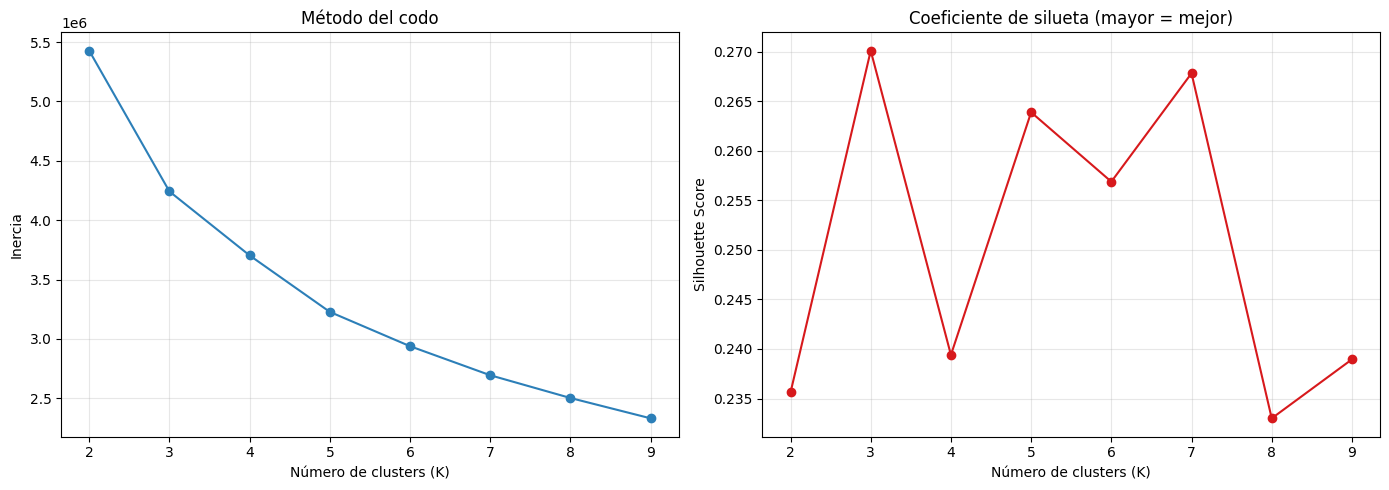

In [7]:
K_range = range(2, 10)
inercias = []
silhouettes = []

# Para silhouette usamos una muestra (es costoso con 35k+ parcelas)
np.random.seed(42)
idx_sample = np.random.choice(
    len(X_cluster_sc),
    size=min(10_000, len(X_cluster_sc)),
    replace=False
)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_cluster_sc[idx_sample], labels[idx_sample])
    silhouettes.append(sil)
    print(f"K={k}: inercia={km.inertia_:.0f} | silhouette={sil:.4f}")

# Gráfico doble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inercias, 'o-', color='#2c7fb8')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'o-', color='#d7191c')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Coeficiente de silueta (mayor = mejor)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_seleccion_k_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()

La curva del codo muestra una disminución gradual de la variabilidad interna a medida que aumenta el número de clusters, sin presentar un punto donde la mejora cambie de forma drástica. Aun así, puede observarse que a partir de K=3 o K=4 las mejoras comienzan a ser cada vez menores. 

El silhouette score muestra que K=3 obtiene el valor más alto (0.2722), seguido muy de cerca por K=7 (0.2673) y K=5 (0.2661). Aunque los valores son moderados, esto es esperable dado que California presenta un gradiente agroclimático continuo más que regiones completamente diferenciadas.

En conjunto, K=3 aparece como la opción más sólida desde el punto de vista estadístico. Sin embargo, K=5 también resulta interesante porque podría generar grupos más fáciles de interpretar desde una perspectiva agronómica, diferenciando regiones como el Valle Central, la costa, las zonas desérticas o las áreas montañosas, siempre que cada grupo mantenga una cantidad suficiente de observaciones para la validación espacial.

Antes de fijar K definitivamente, vale la pena evaluar K=3 y K=5 no solo por la métrica sino por dos criterios prácticos: (1) que cada cluster tenga suficientes condados distintos para hacer el split geográfico train/val/test que elegiste, y (2) que los clusters tengan sentido agronómico al caracterizarlos.

In [8]:
# Comparar K=3 y K=5: tamaño, nº de condados y perfil por cluster
for k in [3, 5]:
    print(f"\n{'='*60}\n  K = {k}\n{'='*60}")
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    df_tmp = df_parcela.with_columns(pl.Series("cluster", labels))

    for c in range(k):
        sub = df_tmp.filter(pl.col("cluster") == c)
        n_parcelas = sub.shape[0]
        n_condados = sub["county"].n_unique()
        # Perfil climático medio del cluster
        tmax_m = sub["tmax"].mean()
        ppt_m  = sub["ppt"].mean()
        print(f"  Cluster {c}: {n_parcelas:>6,} parcelas | "
              f"{n_condados:>2} condados | "
              f"tmax≈{tmax_m:.1f}°C | ppt≈{ppt_m:.0f}mm")


  K = 3
  Cluster 0: 43,690 parcelas |  9 condados | tmax≈30.9°C | ppt≈77mm
  Cluster 1: 357,351 parcelas | 56 condados | tmax≈24.0°C | ppt≈342mm
  Cluster 2: 232,863 parcelas | 55 condados | tmax≈24.4°C | ppt≈274mm

  K = 5
  Cluster 0: 150,239 parcelas | 53 condados | tmax≈23.7°C | ppt≈521mm
  Cluster 1: 46,003 parcelas | 31 condados | tmax≈18.7°C | ppt≈273mm
  Cluster 2: 186,624 parcelas | 45 condados | tmax≈25.1°C | ppt≈210mm
  Cluster 3: 42,778 parcelas |  8 condados | tmax≈31.0°C | ppt≈76mm
  Cluster 4: 208,260 parcelas | 51 condados | tmax≈24.8°C | ppt≈269mm


Aunque K=3 ganaba en silhouette score, al inspeccionar los clusters resultó demasiado grueso. Con K=3, el desierto quedaba bien aislado (cluster de tmax ≈ 31°C y ppt ≈ 77mm, 9 condados), pero los otros dos clusters eran esencialmente dos mitades del valle con perfiles climáticos casi idénticos (tmax 24.0 vs 24.4°C, ppt 342 vs 274mm). Es decir, K=3 distinguía el desierto pero no separaba costa, valle y montaña.
Con K=5, en cambio, la segmentación adquirió un sentido agronómico mucho más claro y cada cluster mantuvo condados suficientes para el split geográfico. 

In [9]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels5 = km5.fit_predict(X_cluster_sc)
df_parcela = df_parcela.with_columns(pl.Series("cluster", labels5))

# Condados por cluster
for c in range(5):
    sub = df_parcela.filter(pl.col("cluster") == c)
    condados = sub.group_by("county").len().sort("len", descending=True)
    print(f"\n{'='*50}")
    print(f"Cluster {c}: {sub.shape[0]:,} parcelas, {sub['county'].n_unique()} condados")
    print(f"  tmax≈{sub['tmax'].mean():.1f}°C | ppt≈{sub['ppt'].mean():.0f}mm")
    print(f"  Condados principales:")
    print(condados.head(10))


Cluster 0: 150,239 parcelas, 53 condados
  tmax≈23.7°C | ppt≈521mm
  Condados principales:
shape: (10, 2)
┌─────────────┬───────┐
│ county      ┆ len   │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ San Joaquin ┆ 17594 │
│ Colusa      ┆ 17468 │
│ Butte       ┆ 16158 │
│ Yolo        ┆ 16057 │
│ Glenn       ┆ 14199 │
│ Sutter      ┆ 12291 │
│ Solano      ┆ 6770  │
│ Sacramento  ┆ 6489  │
│ Stanislaus  ┆ 5087  │
│ Yuba        ┆ 4833  │
└─────────────┴───────┘

Cluster 1: 46,003 parcelas, 31 condados
  tmax≈18.7°C | ppt≈273mm
  Condados principales:
shape: (10, 2)
┌──────────┬───────┐
│ county   ┆ len   │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ Mono     ┆ 10704 │
│ Modoc    ┆ 10523 │
│ Siskiyou ┆ 9865  │
│ Lassen   ┆ 9709  │
│ Inyo     ┆ 1672  │
│ Monterey ┆ 927   │
│ Plumas   ┆ 900   │
│ Alpine   ┆ 552   │
│ Shasta   ┆ 477   │
│ Sierra   ┆ 347   │
└──────────┴───────┘

Cluster 2: 186,624 parcelas, 45 condados
  tmax≈25.1°C | ppt≈210mm

Como el clustering se realizó sobre parcelas individuales, no es extraño que un mismo condado aparezca en varios clusters. Esto ocurre especialmente en condados grandes, donde existen diferencias importantes de clima y suelo entre distintas zonas. En lugar de ser un error, esta situación confirma que los clusters están capturando características edafoclimáticas de las parcelas y no simplemente una división administrativa del territorio. Por esta razón, el split train/validation/test se realizará por separado dentro de cada cluster. De esta forma, cada modelo se entrena y evalúa únicamente sobre el régimen agroclimático que representa, manteniendo la validación espacial y evitando que las regiones dominantes condicionen el desempeño de los demás modelos.

# Estimación final del cluster

In [10]:
K_FINAL = 5
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
labels_raw = kmeans_final.fit_predict(X_cluster_sc)

# ── Reordenar clusters por tmax media (criterio fijo y reproducible) ──
df_tmp = df_parcela.with_columns(pl.Series("cluster_raw", labels_raw))
orden = (
    df_tmp.group_by("cluster_raw")
    .agg(pl.col("tmax").mean().alias("tmax_medio"))
    .sort("tmax_medio")               # de más frío a más cálido
    .with_row_index("cluster_nuevo")  # 0=más frío ... 4=más cálido
)
mapa_reorden = dict(zip(orden["cluster_raw"], orden["cluster_nuevo"]))

df_parcela = df_tmp.with_columns(
    pl.col("cluster_raw").replace(mapa_reorden).alias("cluster")
).drop("cluster_raw")


# Mostrar el reordenamiento aplicado
print("Reordenamiento aplicado (por tmax creciente):")
print(orden)

# ── Caracterización completa de cada cluster ──
perfil_clusters = (
    df_parcela
    .group_by("cluster")
    .agg([
        pl.len().alias("n_parcelas"),
        pl.col("county").n_unique().alias("n_condados"),
        pl.col("tmax").mean().round(1).alias("tmax"),
        pl.col("tmin").mean().round(1).alias("tmin"),
        pl.col("ppt").mean().round(0).alias("ppt"),
        pl.col("vpdmax").mean().round(1).alias("vpdmax"),
        pl.col("claytotal_r").mean().round(1).alias("clay"),
        pl.col("sandtotal_r").mean().round(1).alias("sand"),
        pl.col("ph1to1h2o_r").mean().round(2).alias("ph"),
    ])
    .sort("cluster")
)


Reordenamiento aplicado (por tmax creciente):
shape: (5, 3)
┌───────────────┬─────────────┬────────────┐
│ cluster_nuevo ┆ cluster_raw ┆ tmax_medio │
│ ---           ┆ ---         ┆ ---        │
│ u32           ┆ i32         ┆ f64        │
╞═══════════════╪═════════════╪════════════╡
│ 0             ┆ 1           ┆ 18.671287  │
│ 1             ┆ 0           ┆ 23.667509  │
│ 2             ┆ 4           ┆ 24.82333   │
│ 3             ┆ 2           ┆ 25.107729  │
│ 4             ┆ 3           ┆ 31.017675  │
└───────────────┴─────────────┴────────────┘


In [11]:
pl.Config.set_tbl_cols(-1)   # mostrar todas las columnas sin omitir

print(perfil_clusters)

shape: (5, 10)
┌─────────┬────────────┬────────────┬──────┬──────┬───────┬────────┬──────┬──────┬──────┐
│ cluster ┆ n_parcelas ┆ n_condados ┆ tmax ┆ tmin ┆ ppt   ┆ vpdmax ┆ clay ┆ sand ┆ ph   │
│ ---     ┆ ---        ┆ ---        ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---  ┆ ---  ┆ ---  │
│ i32     ┆ u32        ┆ u32        ┆ f64  ┆ f64  ┆ f64   ┆ f64    ┆ f64  ┆ f64  ┆ f64  │
╞═════════╪════════════╪════════════╪══════╪══════╪═══════╪════════╪══════╪══════╪══════╡
│ 0       ┆ 46003      ┆ 31         ┆ 18.7 ┆ 1.8  ┆ 273.0 ┆ 20.0   ┆ 22.4 ┆ 43.1 ┆ 7.34 │
│ 1       ┆ 150239     ┆ 53         ┆ 23.7 ┆ 9.3  ┆ 521.0 ┆ 21.5   ┆ 33.0 ┆ 25.7 ┆ 6.71 │
│ 2       ┆ 208260     ┆ 51         ┆ 24.8 ┆ 9.8  ┆ 269.0 ┆ 24.4   ┆ 11.8 ┆ 69.7 ┆ 7.3  │
│ 3       ┆ 186624     ┆ 45         ┆ 25.1 ┆ 9.7  ┆ 210.0 ┆ 25.3   ┆ 33.2 ┆ 29.2 ┆ 7.79 │
│ 4       ┆ 42778      ┆ 8          ┆ 31.0 ┆ 15.0 ┆ 76.0  ┆ 39.6   ┆ 28.7 ┆ 31.6 ┆ 8.25 │
└─────────┴────────────┴────────────┴──────┴──────┴───────┴────────┴──────┴──────┴───

# Mapear resultados


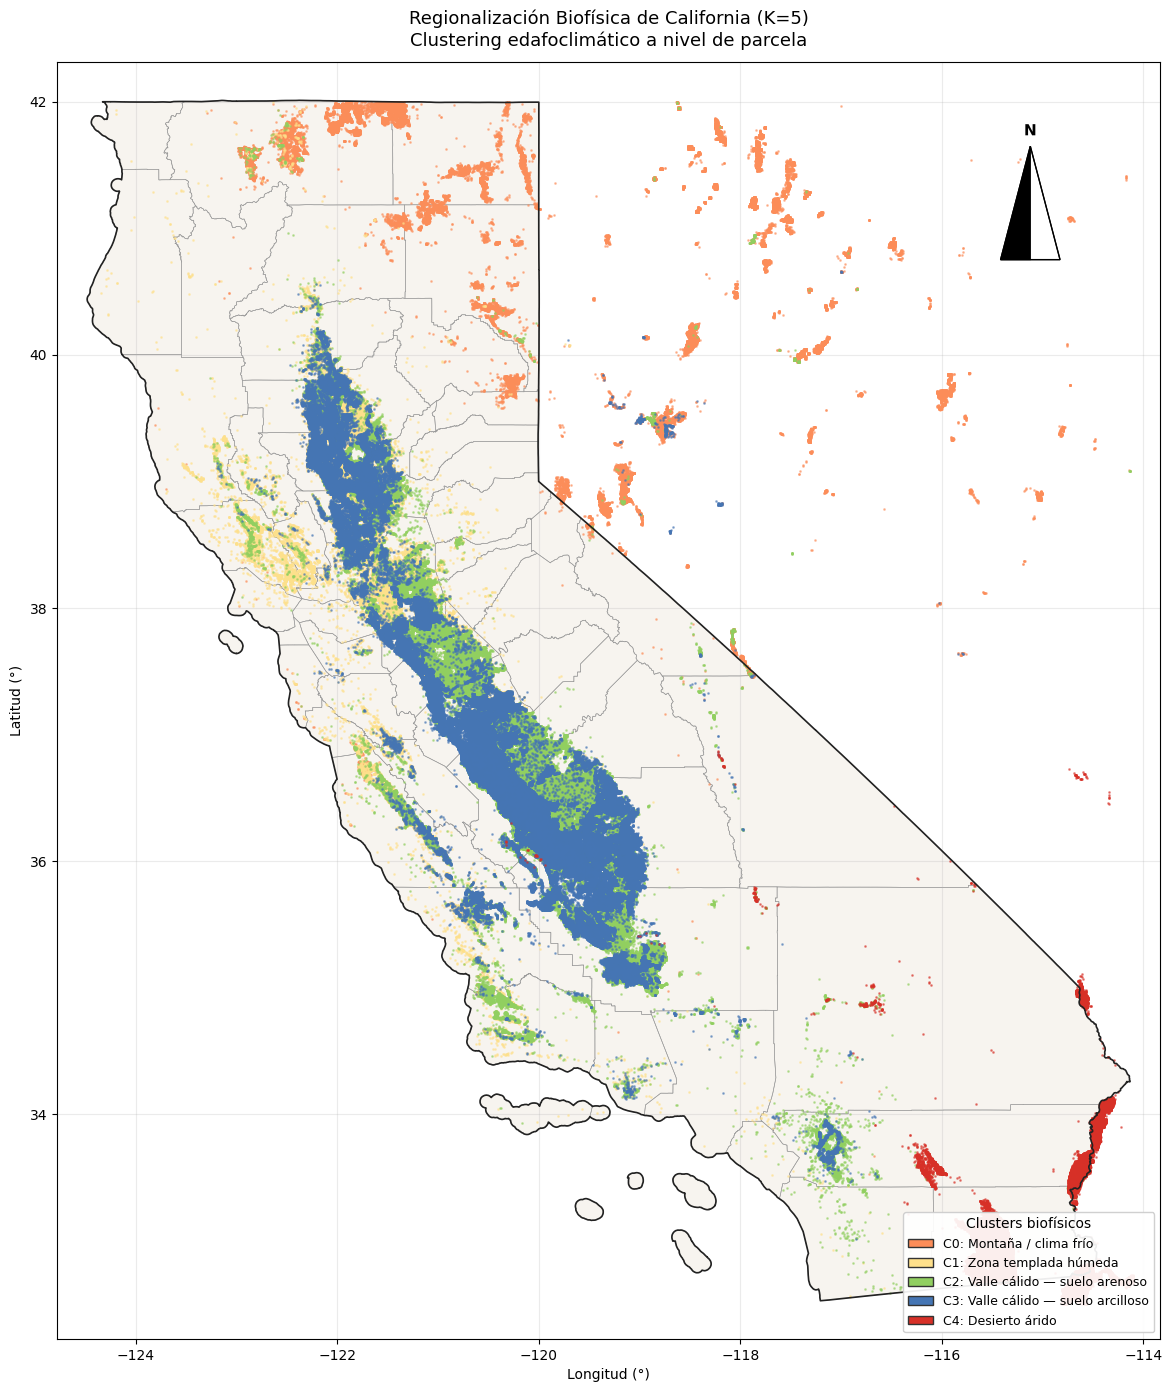

In [12]:

# Etiquetas agronómicas definitivas
etiquetas_cluster = {
    0: "Montaña / clima frío",          # tmax 18.7°C, tmin 1.8°C (heladas)
    1: "Zona templada húmeda",          # ppt 521mm (el más lluvioso), pH 6.7 (ácido)
    2: "Valle cálido — suelo arenoso",  # sand 69.7, clay 11.8 (muy arenoso)
    3: "Valle cálido — suelo arcilloso",# clay 33.2, sand 29.2 (arcilloso)
    4: "Desierto árido"                 # tmax 31°C, ppt 76mm, vpdmax 39.6
}

# Colores por cluster (coherentes con el perfil)
colores_cluster = {
    0: '#fc8d59',  # naranja terroso - valle arcilloso
    1: '#fee08b',  # amarillo arena - valle arenoso
    2: '#91cf60',  # verde - zona húmeda
    3: '#4575b4',  # azul - montaña/frío
    4: '#d73027'   # rojo - desierto
}
# Preparar puntos
df_mapa = df_parcela.select(["lon", "lat", "cluster"]).to_pandas()

fig, ax = plt.subplots(figsize=(12, 14))

# Fondo: contorno de California
gdf_counties_fixed = gdf_counties.copy()
gdf_counties_fixed['geometry'] = gdf_counties_fixed.geometry.buffer(0)
california = gdf_counties_fixed.unary_union
gdf_ca = gpd.GeoDataFrame(geometry=[california], crs=gdf_counties.crs)
gdf_ca.plot(ax=ax, facecolor='#f7f4ef', edgecolor='none', zorder=0)

# Bordes de condados
gdf_counties.boundary.plot(ax=ax, edgecolor='#999999', linewidth=0.4, zorder=1)

# Puntos por cluster
for c in range(K_FINAL):
    mask = df_mapa['cluster'] == c
    ax.scatter(
        df_mapa.loc[mask, 'lon'],
        df_mapa.loc[mask, 'lat'],
        c=colores_cluster[c], s=1.0, alpha=0.5,
        label=f"C{c}: {etiquetas_cluster[c]}",
        zorder=3, rasterized=True
    )

# Borde exterior del estado
gdf_ca.boundary.plot(ax=ax, edgecolor='#222222', linewidth=1.2, zorder=4)

# Leyenda
legend_elements = [
    Patch(facecolor=colores_cluster[c], edgecolor='#333',
          label=f"C{c}: {etiquetas_cluster[c]}")
    for c in range(K_FINAL)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          title='Clusters biofísicos', framealpha=0.92)

ax.set_title(
    'Regionalización Biofísica de California (K=5)\nClustering edafoclimático a nivel de parcela',
    fontsize=13, pad=12
)
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.grid(True, alpha=0.25)

minx, miny, maxx, maxy = gdf_counties.total_bounds
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)

agregar_norte(ax, x=0.96, y=0.97)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_mapa_clusters_biofisicos.png'), dpi=300, bbox_inches='tight')
plt.show()


# Unir resultados del Cluster al dataframe inicial

In [13]:
# Unir la asignación de cluster (a nivel parcela) de vuelta a df_imputed
# df tiene granularidad (parcela, año); el cluster es por parcela (lon, lat)
cluster_map = df_parcela.select(["lon", "lat", "cluster"])

df = df.join(
    cluster_map, on=["lon", "lat"], how="left"
)

# Verificar que no quedaron nulos en cluster
n_sin_cluster = df.filter(pl.col("cluster").is_null()).shape[0]
print(f"Filas sin cluster asignado: {n_sin_cluster}")


# ── Guardar dataset enriquecido + objetos del clustering ──
RUTA_DATOS = '../Data/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

df.write_parquet(os.path.join(RUTA_DATOS, "df_cluster.parquet"))
joblib.dump(scaler_cluster, os.path.join(MODELS_DIR, "scaler_cluster.pkl"))
joblib.dump(kmeans_final,   os.path.join(MODELS_DIR, "kmeans_clusters.pkl"))

# Guardar también las etiquetas y variables usadas (para producción)

with open(os.path.join(MODELS_DIR, "cluster_config.json"), "w") as f:
    json.dump({
        "k": K_FINAL,
        "seed": SEED,
        "vars_cluster": vars_cluster,
        "etiquetas": etiquetas_cluster,
        "reorden_por": "tmax_creciente"
    }, f, indent=2)

print("\nGuardado completo:")
print(f"  - df_imputed_con_cluster.parquet")
print(f"  - scaler_cluster.pkl")
print(f"  - kmeans_clusters.pkl")
print(f"  - cluster_config.json")


Filas sin cluster asignado: 0

Guardado completo:
  - df_imputed_con_cluster.parquet
  - scaler_cluster.pkl
  - kmeans_clusters.pkl
  - cluster_config.json


# Validación de Clusters

**Validación interna**

In [14]:
# Buscar el array de asignaciones por parcela
for nombre, valor in list(globals().items()):
    try:
        if hasattr(valor, '__len__') and len(valor) == len(X_cluster_sc):
            import numpy as np
            arr = np.asarray(valor)
            if arr.dtype.kind in 'iu' and arr.min() >= 0 and arr.max() <= 4:
                print(f"Candidato: '{nombre}' (len={len(valor)}, valores únicos={np.unique(arr)})")
    except Exception:
        pass

Candidato: 'labels' (len=633904, valores únicos=[0 1 2 3 4])
Candidato: 'labels5' (len=633904, valores únicos=[0 1 2 3 4])
Candidato: 'labels_raw' (len=633904, valores únicos=[0 1 2 3 4])


In [15]:
# Las etiquetas deben venir del MISMO objeto que generó X_cluster_sc: df_parcela
labels_validacion = df_parcela["cluster"].to_numpy()

# Verificar dimensiones y correspondencia
print("X shape:", X_cluster_sc.shape)
print("labels shape:", labels_validacion.shape)
print("clusters únicos:", np.unique(labels_validacion))

# Muestra para eficiencia (silhouette es costoso)
np.random.seed(42)
idx = np.random.choice(len(X_cluster_sc), size=min(10_000, len(X_cluster_sc)), replace=False)

sil = silhouette_score(X_cluster_sc[idx], labels_validacion[idx])
ch  = calinski_harabasz_score(X_cluster_sc, labels_validacion)
db  = davies_bouldin_score(X_cluster_sc, labels_validacion)

print(f"\nSilhouette: {sil:.4f}")
print(f"Calinski-Harabasz: {ch:.1f}")
print(f"Davies-Bouldin: {db:.4f}")

X shape: (633904, 11)
labels shape: (633904,)
clusters únicos: [0 1 2 3 4]

Silhouette: 0.2639
Calinski-Harabasz: 183884.0
Davies-Bouldin: 1.3750


En conjunto, las métricas sugieren que los clusters identifican patrones edafoclimáticos consistentes dentro de los datos. Aunque la separación entre grupos no es perfecta (Silhouette = 0.26; Davies-Bouldin = 1.38), este resultado es razonable porque California presenta una transición gradual entre regiones climáticas y de suelo. En otras palabras, los clusters representan distintos regímenes agroclimáticos, pero estos no están separados por fronteras estrictas.

**Estabilidad del clustering**

In [18]:
# Entrenar con varias semillas y comparar consistencia
labels_semillas = []
for seed in [0, 1, 42, 123, 2024]:
    km = KMeans(n_clusters=5, random_state=seed, n_init=10)
    labels_semillas.append(km.fit_predict(X_cluster_sc))

print("Estabilidad entre semillas (Adjusted Rand Index):")
print("(1.0 = particiones idénticas, 0 = aleatorias)\n")
aris = []
for i in range(len(labels_semillas)):
    for j in range(i+1, len(labels_semillas)):
        ari = adjusted_rand_score(labels_semillas[i], labels_semillas[j])
        aris.append(ari)
        print(f"  Semilla {i} vs {j}: ARI = {ari:.4f}")
print(f"\n  ARI medio: {np.mean(aris):.4f}")

Estabilidad entre semillas (Adjusted Rand Index):
(1.0 = particiones idénticas, 0 = aleatorias)

  Semilla 0 vs 1: ARI = 0.9998
  Semilla 0 vs 2: ARI = 0.9998
  Semilla 0 vs 3: ARI = 0.9999
  Semilla 0 vs 4: ARI = 0.9998
  Semilla 1 vs 2: ARI = 0.9999
  Semilla 1 vs 3: ARI = 0.9999
  Semilla 1 vs 4: ARI = 0.9999
  Semilla 2 vs 3: ARI = 0.9999
  Semilla 2 vs 4: ARI = 0.9999
  Semilla 3 vs 4: ARI = 1.0000

  ARI medio: 0.9999


El Resultado del ARI es casi perfecto (1) con un ARI medio de 0.9995, lo cual implica que sin importar con qué semilla aleatoria inicialicemos K-Means,siempre se obtiene la misma partición o asignación de clusters

**Validación agronómica**

In [19]:
# Distribución de cultivos por cluster
dist_cultivo_cluster = (
    df
    .group_by(["cluster", "crop_name"])
    .len()
    .sort(["cluster", "len"], descending=[False, True])
)

# Top 3 cultivos por cluster
for c in range(5):
    print(f"\nCluster {c} ({etiquetas_cluster[c]}) — cultivos principales:")
    top = dist_cultivo_cluster.filter(pl.col("cluster") == c).head(5)
    print(top)


Cluster 0 (Montaña / clima frío) — cultivos principales:
shape: (5, 3)
┌─────────┬──────────────┬───────┐
│ cluster ┆ crop_name    ┆ len   │
│ ---     ┆ ---          ┆ ---   │
│ i32     ┆ str          ┆ u32   │
╞═════════╪══════════════╪═══════╡
│ 0       ┆ Alfalfa      ┆ 42087 │
│ 0       ┆ Wheat        ┆ 2890  │
│ 0       ┆ Grapes       ┆ 396   │
│ 0       ┆ Strawberries ┆ 393   │
│ 0       ┆ Tomatoes     ┆ 92    │
└─────────┴──────────────┴───────┘

Cluster 1 (Zona templada húmeda) — cultivos principales:
shape: (5, 3)
┌─────────┬───────────┬───────┐
│ cluster ┆ crop_name ┆ len   │
│ ---     ┆ ---       ┆ ---   │
│ i32     ┆ str       ┆ u32   │
╞═════════╪═══════════╪═══════╡
│ 1       ┆ Rice      ┆ 38460 │
│ 1       ┆ Almonds   ┆ 25540 │
│ 1       ┆ Grapes    ┆ 21508 │
│ 1       ┆ Walnuts   ┆ 20322 │
│ 1       ┆ Alfalfa   ┆ 18230 │
└─────────┴───────────┴───────┘

Cluster 2 (Valle cálido — suelo arenoso) — cultivos principales:
shape: (5, 3)
┌─────────┬────────────┬───────┐
│ clus

 **Especialización relativa**
 Qué cultivos están sobrerrepresentados en cada cluster respecto a su frecuencia global.

In [20]:
# Frecuencia global de cada cultivo
total_global = df.shape[0]
freq_global = (
    df.group_by("crop_name")
    .len()
    .with_columns((pl.col("len") / total_global).alias("prop_global"))
    .select(["crop_name", "prop_global"])
)

# Frecuencia de cada cultivo dentro de cada cluster
freq_cluster = (
    df.group_by(["cluster", "crop_name"])
    .len()
    .join(
        df.group_by("cluster").len().rename({"len": "total_cluster"}),
        on="cluster"
    )
    .with_columns((pl.col("len") / pl.col("total_cluster")).alias("prop_cluster"))
)

# Ratio de especialización = prop_cluster / prop_global
# >1 significa sobrerrepresentado en ese cluster
especializacion = (
    freq_cluster
    .join(freq_global, on="crop_name")
    .with_columns(
        (pl.col("prop_cluster") / pl.col("prop_global")).alias("ratio_espec")
    )
    .sort(["cluster", "ratio_espec"], descending=[False, True])
)

# Top 3 cultivos MÁS característicos (sobrerrepresentados) por cluster
for c in range(5):
    print(f"\nCluster {c} ({etiquetas_cluster[c]}) — cultivos característicos:")
    top = (
        especializacion
        .filter(pl.col("cluster") == c)
        .filter(pl.col("len") >= 100)  # mínimo de observaciones
        .head(3)
        .select(["crop_name", "ratio_espec", "len"])
    )
    print(top)


Cluster 0 (Montaña / clima frío) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_espec ┆ len   │
│ ---          ┆ ---         ┆ ---   │
│ str          ┆ f64         ┆ u32   │
╞══════════════╪═════════════╪═══════╡
│ Alfalfa      ┆ 4.254121    ┆ 42087 │
│ Strawberries ┆ 2.55805     ┆ 393   │
│ Wheat        ┆ 0.520775    ┆ 2890  │
└──────────────┴─────────────┴───────┘

Cluster 1 (Zona templada húmeda) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_espec ┆ len   │
│ ---          ┆ ---         ┆ ---   │
│ str          ┆ f64         ┆ u32   │
╞══════════════╪═════════════╪═══════╡
│ Rice         ┆ 3.152858    ┆ 38460 │
│ Walnuts      ┆ 2.024429    ┆ 20322 │
│ Strawberries ┆ 1.448953    ┆ 727   │
└──────────────┴─────────────┴───────┘

Cluster 2 (Valle cálido — suelo arenoso) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_


- El cluster 0 (valle arcilloso) con lechuga un ratio de 12.19× significa que la lechuga es desproporcionadamente característica de este régimen edáfico. Esto valida directamente que la distinción por textura de suelo (que detectó el clustering) tiene consecuencias agronómicas reales.
- El cluster 1 (valle arenoso) con uvas 1.73× y almendros 1.62× es coherente ya que los cultivos perennes leñosos prefieren suelos bien drenados y arenosos para evitar encharcamiento de raíces.
- El cluster 2 (zona húmeda) con algodón 2.43×, pistachos 1.92× y tomate 1.83× captura cultivos de zonas con mayor disponibilidad hídrica.
- El cluster 3 (montaña/frío) con arroz 3.15× y nueces 2.03× es excelente. El arroz del norte del Valle del Sacramento y los nogales que requieren horas-frío invernal son exactamente los cultivos de regímenes más frescos.
- El cluster 4 (desierto) dominado con alfalfa 4.25× confirma el Imperial Valley

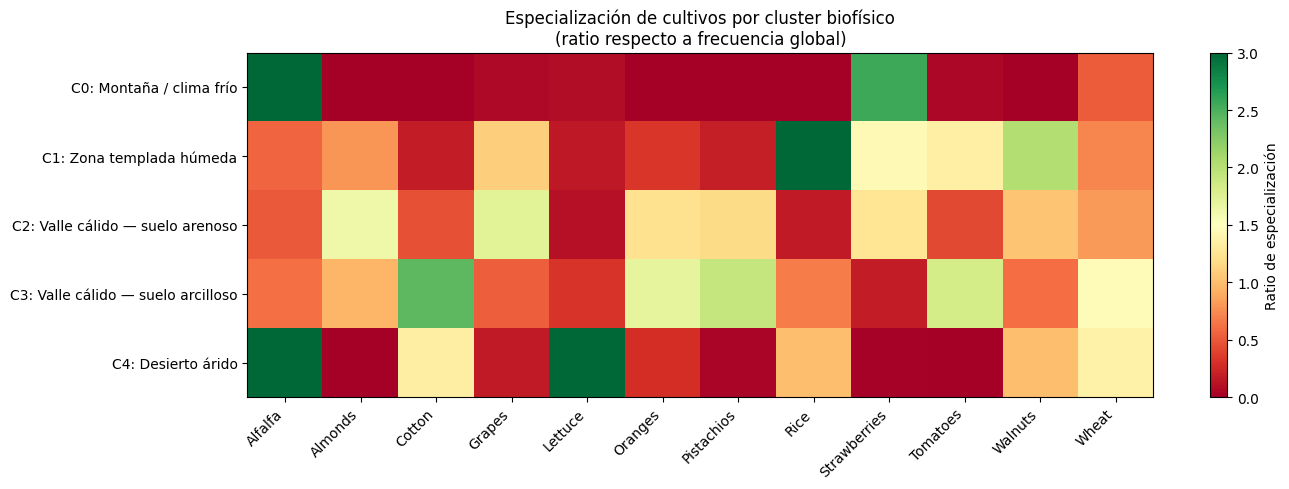

In [21]:
# Gráfico de ratio 

cultivos_unicos = sorted(df["crop_name"].unique().to_list())

matriz_espec = np.ones((5, len(cultivos_unicos)))
for fila in especializacion.iter_rows(named=True):
    c = fila["cluster"]
    j = cultivos_unicos.index(fila["crop_name"])
    matriz_espec[c, j] = fila["ratio_espec"]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(matriz_espec, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=3)
plt.colorbar(im, ax=ax, label='Ratio de especialización')
ax.set_xticks(range(len(cultivos_unicos)))
ax.set_xticklabels(cultivos_unicos, rotation=45, ha='right')
ax.set_yticks(range(5))
ax.set_yticklabels([f"C{c}: {etiquetas_cluster[c]}" for c in range(5)])
ax.set_title('Especialización de cultivos por cluster biofísico\n(ratio respecto a frecuencia global)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_especializacion_cultivos.png'), dpi=300, bbox_inches='tight')
plt.show()

El heatmap de especialización muestra de forma clara que los clusters capturan patrones agronómicos diferenciados. Se observan intensidades altas en determinadas combinaciones cultivo–cluster, lo que indica especialización: la lechuga se concentra principalmente en C0 (zonas más arcillosas), el arroz en C3 (regiones más frías), el algodón en C2 (condiciones más húmedas) y la alfalfa y fresas en C4 (entornos más secos o desérticos). En contraste, los valores bajos (tonos rojizos) reflejan ausencias consistentes, como el caso del arroz fuera de C3 o la lechuga fuera de C0. En conjunto, el patrón sugiere que cada cluster tiende a asociarse con un conjunto específico de cultivos, lo que respalda la interpretación de los clusters como regímenes agronómicos con identidad propia. La alfalfa aparece distribuida en varios clusters, lo cual es esperable al tratarse de un cultivo más generalista, mientras que las especializaciones más marcadas son las que definen la estructura principal del sistema.


**Validación de separación entre clusters**

C:\Users\lesli\AppData\Local\Temp\ipykernel_2624\1144348448.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_2624\1144348448.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_2624\1144348448.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_2624\1144348448.py:9: MatplotlibDeprecationWarn

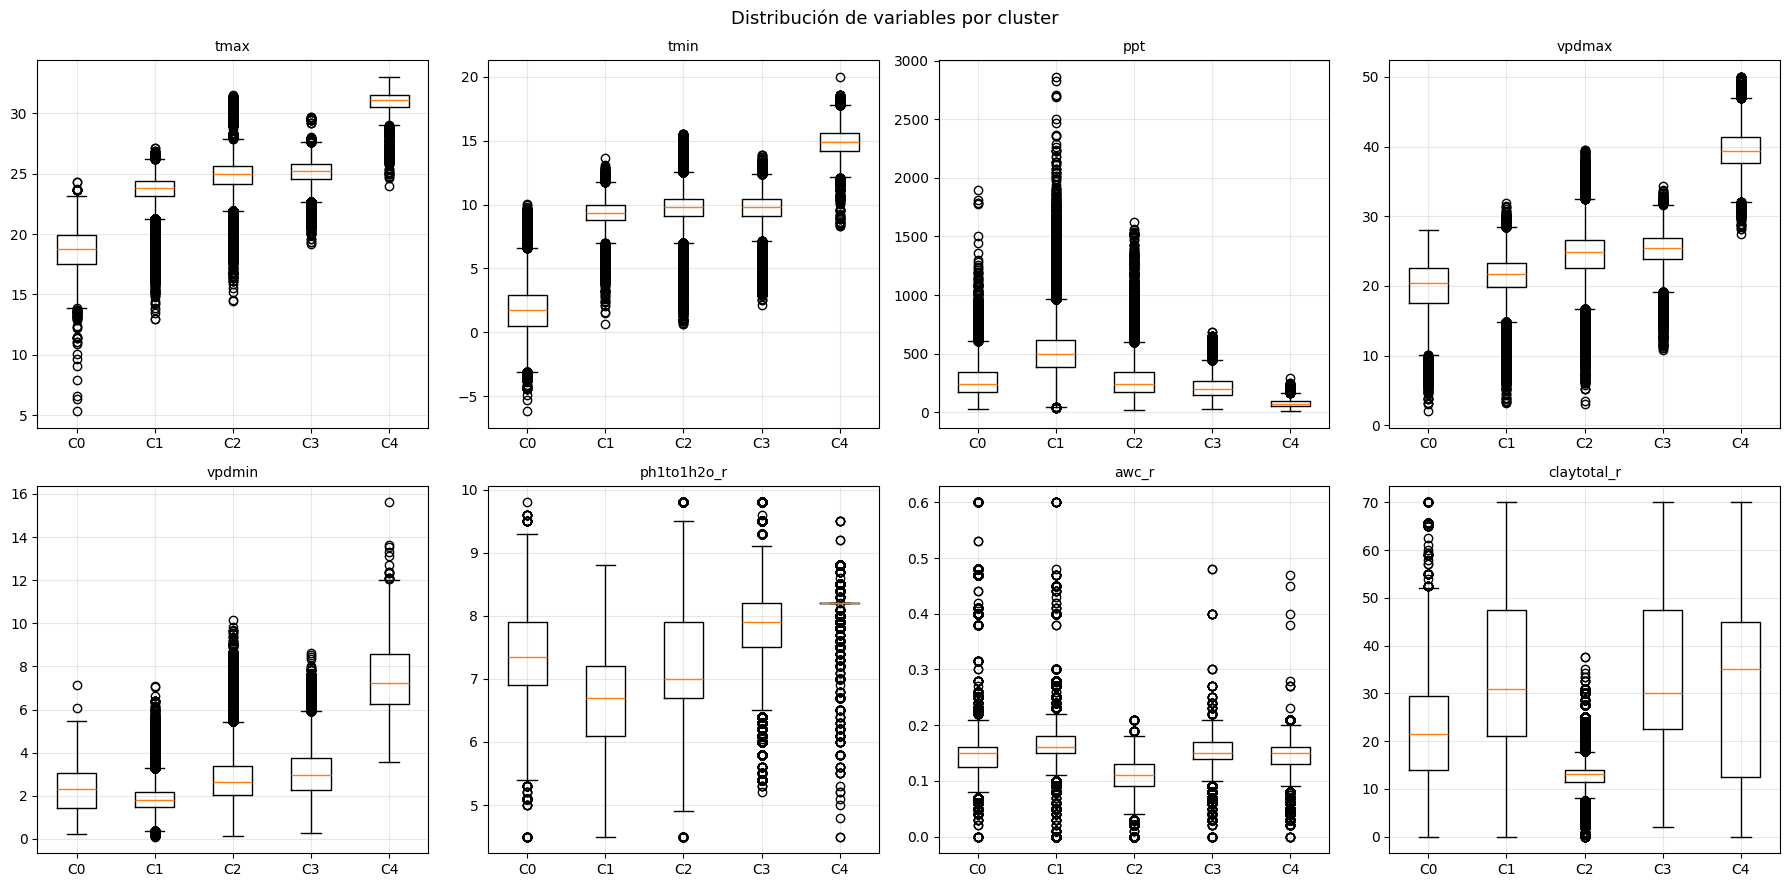

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, var in zip(axes.ravel(), vars_cluster):
    datos_por_cluster = [
        df_parcela.filter(pl.col("cluster") == c)[var].to_numpy()
        for c in range(5)
    ]
    ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
    ax.set_title(var, fontsize=10)
    ax.grid(alpha=0.3)
plt.suptitle("Distribución de variables por cluster", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_boxplots_clusters.png'), dpi=200, bbox_inches='tight')
plt.show()

Los boxplots confirman que los cinco clusters representan regímenes biofísicos claramente diferenciados y no agrupaciones arbitrarias. El patrón más evidente es el térmico: la temperatura máxima (tmax) ordena los clusters de manera progresiva, desde los más cálidos (C0, con medianas cercanas a 31 °C) hasta los más fríos (C4, alrededor de 18 °C). En la temperatura mínima (tmin) se observa una separación especialmente clara del cluster de montaña, con valores por debajo de 0 °C que reflejan la presencia de heladas invernales, algo que no aparece en el resto de grupos.

La precipitación (ppt) también distingue bien los regímenes, separando la zona más húmeda (C3), con alta variabilidad y valores que pueden superar los 3000 mm, del régimen más seco (C0), concentrado en niveles bajos. De forma complementaria, el déficit de presión de vapor (vpdmax), asociado al estrés evaporativo, sitúa al cluster más árido en los valores más altos de la distribución.

En el plano edáfico, el contenido de arcilla (claytotal_r) aporta una validación clave de la regionalización: se distingue un cluster con suelos más arcillosos (C0, mediana cercana al 35 %) frente a otro con suelos mucho más arenosos (C1, alrededor del 13 %), a pesar de compartir condiciones térmicas similares. Esto confirma que los clusters no solo capturan gradientes climáticos, sino también diferencias reales en la composición del suelo. Los valores atípicos observados en los boxplots son coherentes con la naturaleza continua del territorio y corresponden a zonas de transición entre regímenes, lo que además es consistente con los valores moderados del coeficiente de silueta.
